In [304]:
import pandas as pd
import numpy as np

In [305]:
df = pd.read_csv('/content/drive/MyDrive/titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [306]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [307]:
df = df.drop('Cabin', axis=1, errors='ignore')

In [308]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age']

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [309]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [310]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(df['Sex'].unique())

[0 1]


In [311]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

print(df['Embarked'].unique())

[2 0 1]


In [312]:
df = df.drop(['PassengerId','Survived' ,'Name', 'Ticket'], axis=1)
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.000000,1,0,7.2500,2
1,1,1,38.000000,1,0,71.2833,0
2,3,1,26.000000,0,0,7.9250,2
3,1,1,35.000000,1,0,53.1000,2
4,3,0,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,13.0000,2
887,1,1,19.000000,0,0,30.0000,2
888,3,1,29.699118,1,2,23.4500,2
889,1,0,26.000000,0,0,30.0000,0


In [313]:
y = df['Fare'] #Fare와 Pclass 관련있음

In [314]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [315]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
preds_lr = model.predict(X_test)

print('평균제곱오차', mean_squared_error(preds_lr, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(preds_lr, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(preds_lr, y_test))

평균제곱오차 1098.7183559556443
평균제곱오차 1098.7183559556443
평균제곱오차 1098.7183559556445


In [316]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=0)
model.fit(X_train, y_train)
preds_dt = model.predict(X_test)

print('평균제곱오차', mean_squared_error(preds_dt, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(preds_dt, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(preds_dt, y_test))

평균제곱오차 1988.0486766000445
평균제곱오차 1988.0486766000445
평균제곱오차 1988.0486766000447


In [317]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
preds_rt = model.predict(X_test)

print('평균제곱오차', mean_squared_error(preds_rt , y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(preds_rt , y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(preds_rt , y_test))

평균제곱오차 920.6325885584964
평균제곱오차 920.6325885584964
평균제곱오차 920.6325885584959


In [318]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

pred_knn = model.predict(X_test)

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


평균제곱오차 1542.937880541697
평균제곱오차 1542.937880541697
평균제곱오차 1542.937880541696


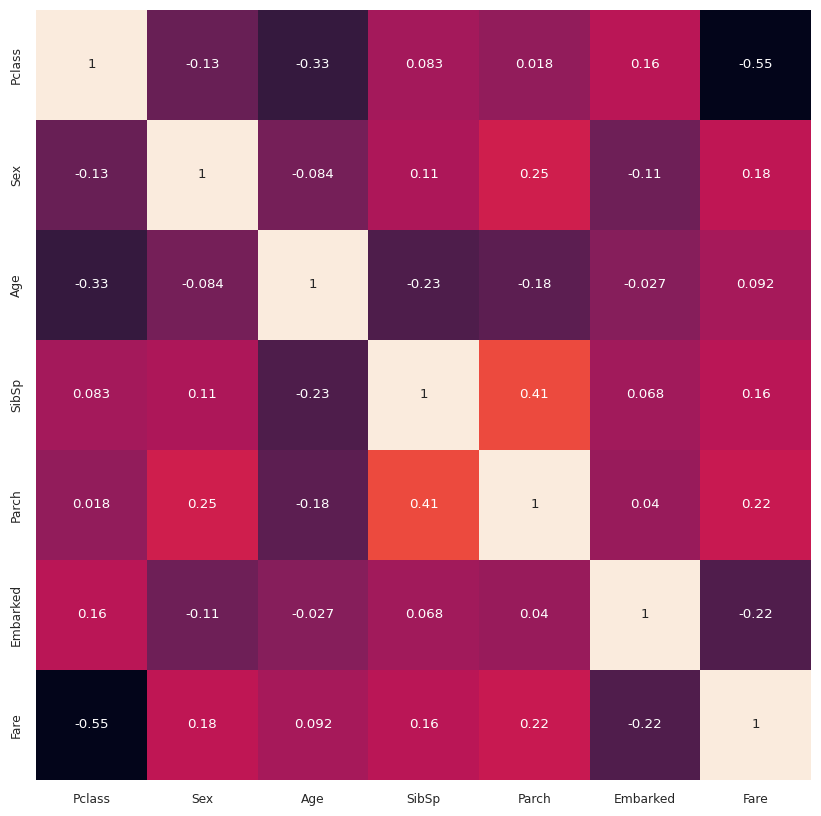

In [319]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()


plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [320]:
X = df.drop(['Fare'], axis=1)
y = df['Fare']

In [321]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [322]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
preds_lr = model.predict(X_test)

print('평균제곱오차', mean_squared_error(preds_lr, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(preds_lr, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(preds_lr, y_test))

평균제곱오차 1098.7183559556443
평균제곱오차 1098.7183559556443
평균제곱오차 1098.7183559556445


In [323]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=0)
model.fit(X_train, y_train)
preds_dt = model.predict(X_test)

print('평균제곱오차', mean_squared_error(preds_dt, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(preds_dt, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(preds_dt, y_test))

평균제곱오차 1988.0486766000445
평균제곱오차 1988.0486766000445
평균제곱오차 1988.0486766000447


In [324]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
preds_rt = model.predict(X_test)

print('평균제곱오차', mean_squared_error(preds_rt , y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(preds_rt , y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(preds_rt , y_test))

평균제곱오차 920.6325885584964
평균제곱오차 920.6325885584964
평균제곱오차 920.6325885584959


In [325]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

pred_knn = model.predict(X_test)

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


평균제곱오차 1542.937880541697
평균제곱오차 1542.937880541697
평균제곱오차 1542.937880541696


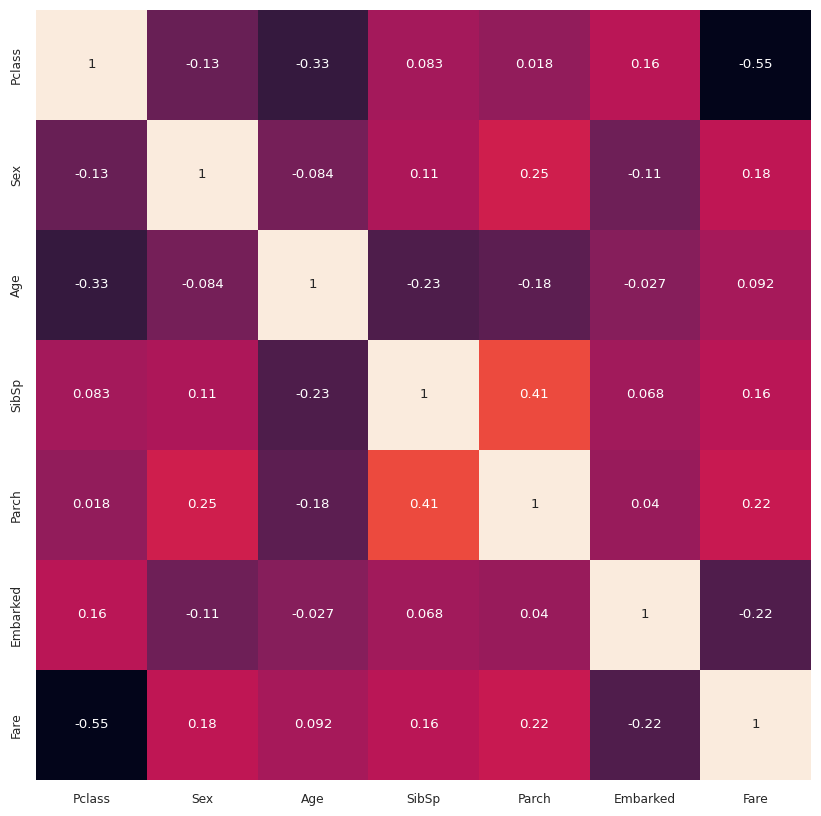

In [326]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()


plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()